# MLP Neural Classification — IBL Brain-Wide Map

This notebook trains a simple **multi-layer perceptron (MLP)** decoder on IBL spiking data to classify a behavioral variable from neural activity.

The key idea is to compare how well different brain regions encode a particular behavioral variable. We compare three conditions:
- **Motor cortex only** — neurons from motor areas
- **Caudoputamen only** — neurons from basal ganglia
- **Both regions combined** — the union of the two above

The classification performance is measured with **MCC (Matthews Correlation Coefficient)**, which is the direct analog of Pearson r for binary classification: it ranges from -1 (perfectly wrong) to +1 (perfect), with 0 = chance, and handles class imbalance correctly.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_brain.transforms import UnitFilter, Compose

from mlp import MLPNeuralClassifier
from aux_functions import (
    get_loaders,
    get_unit_ids,
    move_to_device,
    training_step,
    compute_classification_metrics,
    plot_cls_training_curves,
    run_cls_test,
    plot_cls_mcc_bar,
    plot_cls_confusion_matrices,
    plot_population_mcc,
)

## 2. Configuration

Key hyperparameters:
- **BIN_SIZE**: spike bin width in seconds (10 ms → 100 bins/second)
- **SEQUENCE_LENGTH**: sliding-window duration used as model input (1 second)
- **HIDDEN_DIM**: number of units in the MLP hidden layer
- **TASK_CLS**: the task-aligned interval name in the HDF5 files — determines which behavioral windows are sampled
- **LABEL_MAP**: maps raw label strings stored in the HDF5 file to integer class indices (e.g. `"left" → 0`, `"right" → 1`)

In [2]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda:0") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

# ── Hyperparameters ────────────────────────────────────────────────────────
BIN_SIZE        = 10e-3   # 10 ms → 100 input bins / second
SEQUENCE_LENGTH = 1.0     # 1-second windows
HIDDEN_DIM      = 256
NUM_EPOCHS      = 10
LR              = 1e-4
QUALITY_SCORE   = 0.6

# ── Task ───────────────────────────────────────────────────────────────────
TASK_CLS  = "choice"         # task-aligned interval name in the h5 files
LABEL_MAP = {"left": 0, "right": 1}   # IBL choice strings: left=0, right=1

Using device: mps


## 3. Dataset & Data Loaders

Load one IBL recording and construct three DataLoaders (train / validation / test). The dataset samples **1-second windows aligned to task events** (`TASK_CLS`), ensuring the model only sees windows during which the animal was actively performing the task. The same dataset object is shared across all three loaders — the transform containing the unit filter and tokenizer is swapped in-place for each experiment.

In [3]:
recording_ids = [
    #"sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys",
    #"sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys",
    "sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys",
    #"sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys",
    #"sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys",
    #"sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys",
    #"sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys",
    #"sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-e56541a5-a6d5-4750-b1fe-f6b5257bfe7c_desc-processed_behavior+ecephys",
]

dir_path = Path(".").resolve()

dataset_cls, train_loader_cls, val_loader_cls, test_loader_cls = get_loaders(
    dir_path=dir_path,
    recording_ids=recording_ids,
    readout_id="wheel_velocity",
    task="choice",
    valid_labels=set(LABEL_MAP.keys()),    # ← filters out "no_go" trials
    window_length=SEQUENCE_LENGTH,
    batch_size=16,
)


print(f"Recordings  : {len(dataset_cls.recording_ids)}")
print(f"Total units : {len(dataset_cls.get_unit_ids())}")
print(f"Train batches: {len(train_loader_cls)}  |  Val: {len(val_loader_cls)}  |  Test: {len(test_loader_cls)}")

Recordings  : 1
Total units : 2856
Train batches: 44  |  Val: 7  |  Test: 13


## 4. Model Training

For each experiment (brain-region combination) we:
1. Select units matching the area filter string and a minimum quality score
2. Instantiate a fresh `MLPNeuralClassifier` for the selected unit count
3. Apply the unit filter + model tokenizer as the dataset transform
4. Train with **AdamW + cross-entropy loss** for `NUM_EPOCHS` epochs
5. Compute validation **MCC** before each epoch to monitor learning

The model receives a binned spike-count tensor of shape `(num_units × time_bins)` and outputs logits for 2 classes.

In [4]:
experiments_cls = {
    "motor":        {"filter_strs": ["motor"]},
    "caudoputamen": {"filter_strs": ["caudoputamen"]},
    "both":         {"filter_strs": ["motor", "caudoputamen"]},
}

cls_models       = {}
cls_loss_logs    = {}
cls_mcc_logs     = {}
cls_unit_filters = {}

for label, cfg in experiments_cls.items():
    unit_ids = get_unit_ids(dataset_cls, filter_str=cfg["filter_strs"], quality_score=QUALITY_SCORE)
    print(f"\n── {label}  ({len(unit_ids)} units) ──")

    valid_set   = set(unit_ids)
    unit_filter = UnitFilter(
        mask_fn=lambda units, vs=valid_set: np.array([uid in vs for uid in units.id]),
        field="spikes",
        reset_index=True,
    )
    cls_unit_filters[label] = unit_filter

    model = MLPNeuralClassifier(
        num_units=len(unit_ids),
        bin_size=BIN_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        task=TASK_CLS,
        num_classes=2,
        label_map=LABEL_MAP,
        hidden_dim=HIDDEN_DIM,
    ).to(device).float()

    dataset_cls.transform = Compose([unit_filter, model.tokenize])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    loss_log = []
    mcc_log  = []
    for epoch in range(NUM_EPOCHS):
        # ── validation before training (analogous to compute_r2 in regression) ──
        val_metrics = compute_classification_metrics(val_loader_cls, model)
        mcc_log.append(val_metrics["mcc"])

        # ── training ──
        model.train()
        epoch_loss = 0.0
        for batch in train_loader_cls:
            batch = move_to_device(batch, device)
            loss = training_step(batch, model, optimizer, task_type="classification")
            loss_log.append(loss.item())
            epoch_loss += loss.item()
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader_cls):.4f}  val_MCC={val_metrics['mcc']:.3f}")

    # final validation
    val_metrics = compute_classification_metrics(val_loader_cls, model)
    mcc_log.append(val_metrics["mcc"])

    cls_models[label]    = model
    cls_loss_logs[label] = loss_log
    cls_mcc_logs[label]  = mcc_log
    print(f"\u2705 {label} done  final val MCC={val_metrics['mcc']:.3f}")


── motor  (160 units) ──
  Epoch   1/10  loss=0.6247  val_MCC=0.000
  Epoch   2/10  loss=0.2820  val_MCC=0.780
  Epoch   3/10  loss=0.0541  val_MCC=0.818
  Epoch   4/10  loss=0.0131  val_MCC=0.820
  Epoch   5/10  loss=0.0056  val_MCC=0.799
  Epoch   6/10  loss=0.0032  val_MCC=0.799
  Epoch   7/10  loss=0.0020  val_MCC=0.820
  Epoch   8/10  loss=0.0013  val_MCC=0.820
  Epoch   9/10  loss=0.0010  val_MCC=0.802
  Epoch  10/10  loss=0.0007  val_MCC=0.802
✅ motor done  final val MCC=0.802

── caudoputamen  (283 units) ──
  Epoch   1/10  loss=0.4419  val_MCC=-0.078
  Epoch   2/10  loss=0.0603  val_MCC=0.940
  Epoch   3/10  loss=0.0106  val_MCC=0.980
  Epoch   4/10  loss=0.0039  val_MCC=0.980
  Epoch   5/10  loss=0.0021  val_MCC=0.980
  Epoch   6/10  loss=0.0014  val_MCC=0.980
  Epoch   7/10  loss=0.0009  val_MCC=0.980
  Epoch   8/10  loss=0.0006  val_MCC=0.980
  Epoch   9/10  loss=0.0005  val_MCC=0.980
  Epoch  10/10  loss=0.0003  val_MCC=0.980
✅ caudoputamen done  final val MCC=0.980

── b

## 5. Training Curves

**Left:** Validation MCC per epoch — dashed line at 0 = chance level. A rising curve means the model is learning to decode the behavioral variable.

**Right:** Cross-entropy training loss per gradient step.

All three region experiments are overlaid for direct comparison.

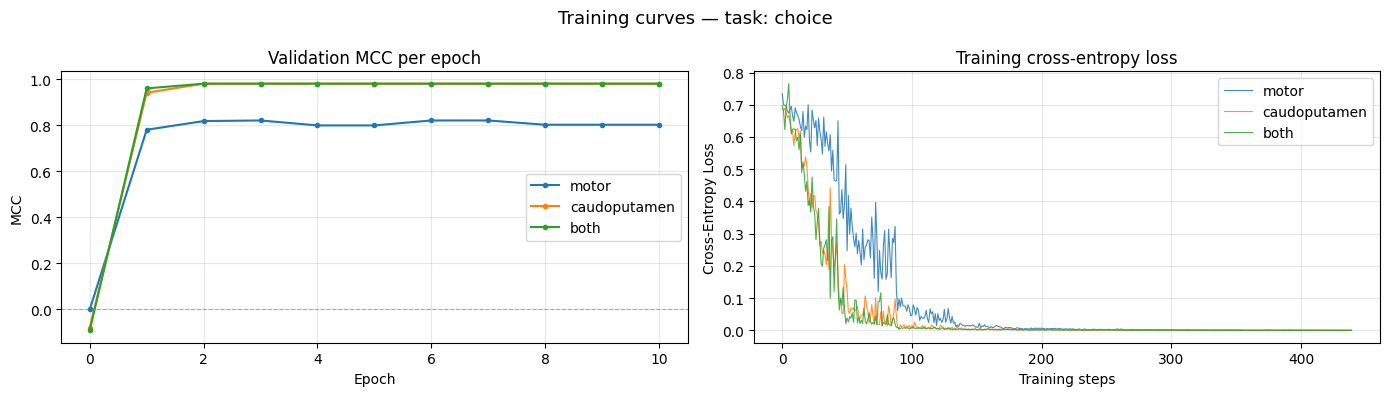

In [5]:
plot_cls_training_curves(cls_mcc_logs, cls_loss_logs, task=TASK_CLS)

## 6. Test Set Evaluation

Run each trained model on the held-out **test split** (never seen during training or validation) and report the final MCC for each brain-region condition.

In [6]:
cls_test_metrics, cls_test_preds, cls_test_targets_arr = run_cls_test(
    dataset=dataset_cls,
    test_loader=test_loader_cls,
    cls_models=cls_models,
    cls_unit_filters=cls_unit_filters,
    device=device,
    transform_cls=Compose,
)

motor            MCC=0.811
caudoputamen     MCC=0.910
both             MCC=0.920


## 7. Results — MCC Comparison

Test MCC for each region condition. Higher bars indicate stronger encoding of the behavioral variable in that brain region.

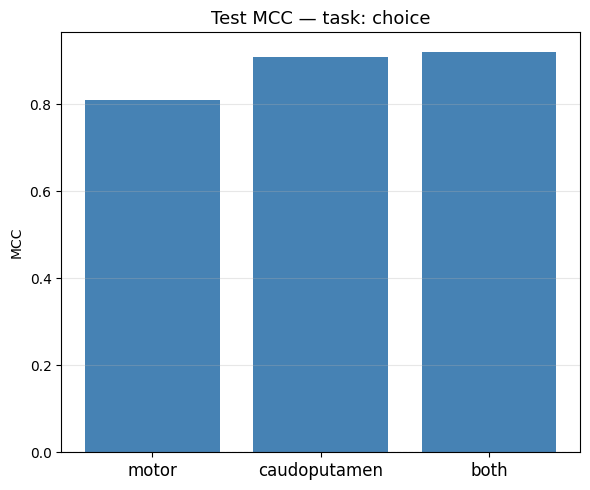

In [7]:
plot_cls_mcc_bar(cls_test_metrics, task=TASK_CLS)

## 8. Confusion Matrices

One confusion matrix per experiment: rows = ground truth, columns = predicted class. The MCC score is shown in each subplot title. Off-diagonal cells are misclassified trials — a perfectly balanced classifier would have zeros off-diagonal.

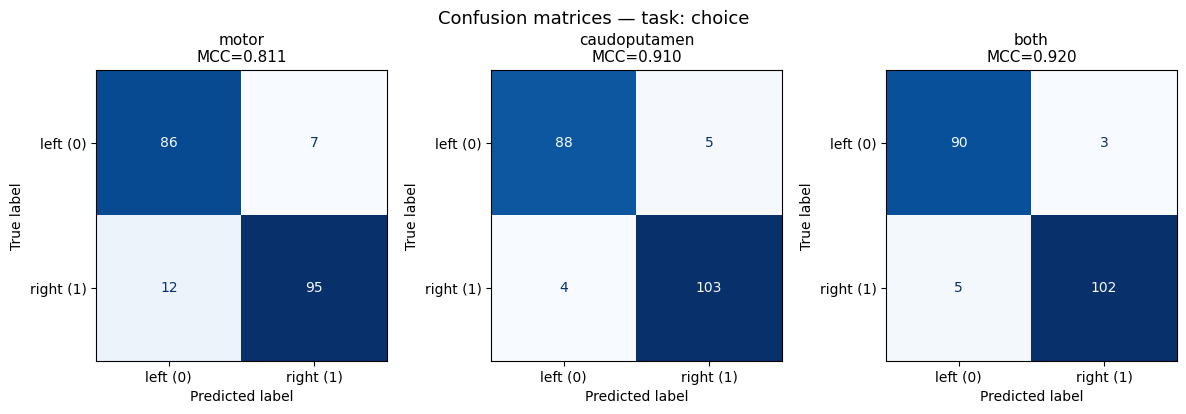

In [8]:
plot_cls_confusion_matrices(
    cls_test_metrics,
    cls_test_preds,
    cls_test_targets_arr,
    task=TASK_CLS,
    class_names=["left (0)", "right (1)"],
)

## 9. Population Analysis — Does the difference hold across sessions?

We now loop over **all available sessions**, fit the same three classifiers (motor / caudoputamen / both) for each session independently, collect the test MCC, and plot the full distribution across sessions.

This tells us whether the difference in choice encoding between brain areas is a **consistent population-level effect** or just a feature of the specific session we used above.

> ⚠️ This cell is slow — it trains `n_sessions × 3` models. Reduce `NUM_EPOCHS` if needed for a quick check.


In [9]:
all_recording_ids = [
    "sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys",
    "sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys",
    "sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys",
    "sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys",
    "sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys",
    "sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys",
    "sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys",
    "sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys",
    "sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys",
    "sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys",
    "sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys",
    "sub-CSH-ZAD-026_ses-e56541a5-a6d5-4750-b1fe-f6b5257bfe7c_desc-processed_behavior+ecephys",
]

NUM_EPOCHS = 4

# population_results[session_id][region_label] = test_mcc
population_results = {}

for rid in all_recording_ids:
    print(f"\n{'='*70}\n  Session: {rid}\n{'='*70}")

    dataset_s, train_s, val_s, test_s = get_loaders(
        dir_path=dir_path,
        recording_ids=[rid],
        readout_id="wheel_velocity",
        task="choice",
        valid_labels=set(LABEL_MAP.keys()),    # ← filters out "no_go" trials
        window_length=SEQUENCE_LENGTH,
        batch_size=16,
    )


    session_results = {}
    for label, cfg in experiments_cls.items():
        unit_ids = get_unit_ids(dataset_s, filter_str=cfg["filter_strs"], quality_score=QUALITY_SCORE)
        if len(unit_ids) == 0:
            print(f"  [{label}] no units — skipping")
            session_results[label] = float("nan")
            continue

        print(f"  [{label}] {len(unit_ids)} units", end="", flush=True)

        unit_filter = UnitFilter(
            mask_fn=lambda units, vs=set(unit_ids): np.array([uid in vs for uid in units.id]),
            field="spikes",
            reset_index=True,
        )
        model = MLPNeuralClassifier(
            num_units=len(unit_ids),
            bin_size=BIN_SIZE,
            sequence_length=SEQUENCE_LENGTH,
            task=TASK_CLS,
            num_classes=2,
            label_map=LABEL_MAP,
            hidden_dim=HIDDEN_DIM,
        ).to(device).float()

        dataset_s.transform = Compose([unit_filter, model.tokenize])
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

        for _ in range(NUM_EPOCHS):
            model.train()
            for batch in train_s:
                batch = move_to_device(batch, device)
                training_step(batch, model, optimizer, task_type="classification")

        metrics = compute_classification_metrics(test_s, model)
        session_results[label] = metrics["mcc"]
        print(f"  →  test MCC = {metrics['mcc']:.3f}")

    population_results[rid] = session_results


  Session: sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys
  [motor] 265 units  →  test MCC = 0.804
  [caudoputamen] 345 units  →  test MCC = 0.854
  [both] 610 units  →  test MCC = 0.804

  Session: sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys
  [motor] 155 units  →  test MCC = 0.901
  [caudoputamen] 119 units  →  test MCC = 0.593
  [both] 274 units  →  test MCC = 0.885

  Session: sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys
  [motor] 160 units  →  test MCC = 0.840
  [caudoputamen] 283 units  →  test MCC = 0.879
  [both] 443 units  →  test MCC = 0.920

  Session: sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys
  [motor] 65 units  →  test MCC = 0.818
  [caudoputamen] 143 units  →  test MCC = 0.858
  [both] 208 units  →  test MCC = 0.929

  Session: sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys
  [

  →  test MCC = 0.844
  [caudoputamen] 199 units  →  test MCC = 0.724
  [both] 341 units  →  test MCC = 0.864

  Session: sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys
  [motor] 208 units

  →  test MCC = 0.843
  [caudoputamen] 189 units  →  test MCC = 0.879
  [both] 397 units  →  test MCC = 0.855

  Session: sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys
  [motor] 141 units

  →  test MCC = 0.494
  [caudoputamen] 179 units  →  test MCC = 0.678
  [both] 320 units  →  test MCC = 0.674

  Session: sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys
  [motor] 246 units  →  test MCC = 0.863
  [caudoputamen] 179 units  →  test MCC = 0.590
  [both] 425 units  →  test MCC = 0.848

  Session: sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys
  [motor] 460 units  →  test MCC = 0.908
  [caudoputamen] 147 units  →  test MCC = 0.875
  [both] 607 units  →  test MCC = 0.899

  Session: sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys
  [motor] 177 units  →  test MCC = 0.928
  [caudoputamen] 586 units  →  test MCC = 0.916
  [both] 763 units  →  test MCC = 0.928

  Session: sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys
  [motor] 65 units  →  test MCC = 0.650
  [caudoputamen] 256 units  →  test MCC = 0.510
  [both] 321 

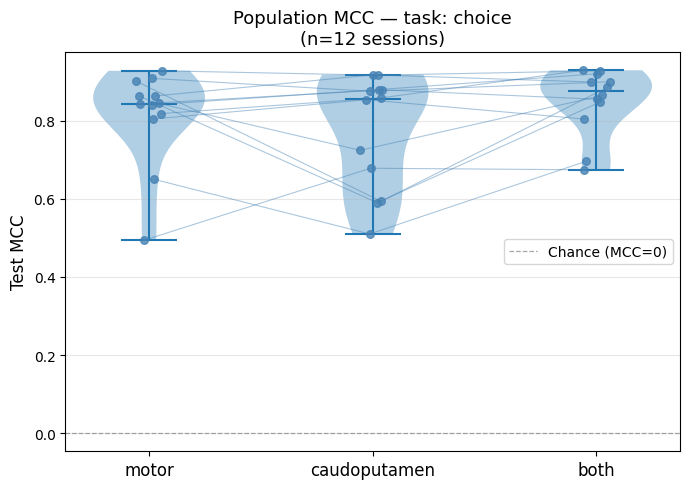

In [10]:
plot_population_mcc(population_results, task=TASK_CLS)